# 4. Model Evaluation

## Summary
Thorough analysis of the trained DroneCNN on the held-out test set.

### Contents
1. Load model and test data
2. Predictions and threshold selection (ROC / Precision-Recall)
3. Confusion matrix (absolute and normalised)
4. Per-class metrics: Precision, Recall, F1, AUC
5. Error analysis – false positives and false negatives
6. Calibration curve
7. SNR robustness simulation
8. Results summary table


### Imports

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import calibration_curve

SEED = 42
np.random.seed(SEED)
os.makedirs("plots", exist_ok=True)

CLASS_NAMES = ["Non-drone", "Drone"]


## 4.1  Load model and test data

In [2]:
model  = keras.models.load_model("best_drone_cnn.keras")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

with open("training_meta.json") as f:
    meta = json.load(f)

print(f"Test set: {X_test.shape}  — {y_test.sum()} drone, {(y_test==0).sum()} non-drone")
print(f"Model input shape: {model.input_shape}")


Test set: (278, 10, 40, 1)  — 98 drone, 180 non-drone
Model input shape: (None, 10, 40, 1)


## 4.2  Predictions

In [3]:
y_prob = model.predict(X_test, batch_size=128, verbose=0).ravel()   # sigmoid probability
y_pred = (y_prob >= 0.5).astype(int)                                 # default threshold

test_metrics = model.evaluate(X_test, y_test, batch_size=128, verbose=0)
metric_names = model.metrics_names
print("\nTest set evaluation (threshold = 0.5):")
for name, val in zip(metric_names, test_metrics):
    print(f"  {name:<12} {val:.4f}")



Test set evaluation (threshold = 0.5):
  loss         0.7267
  compile_metrics 0.3525


## 4.3  ROC and Precision-Recall curves

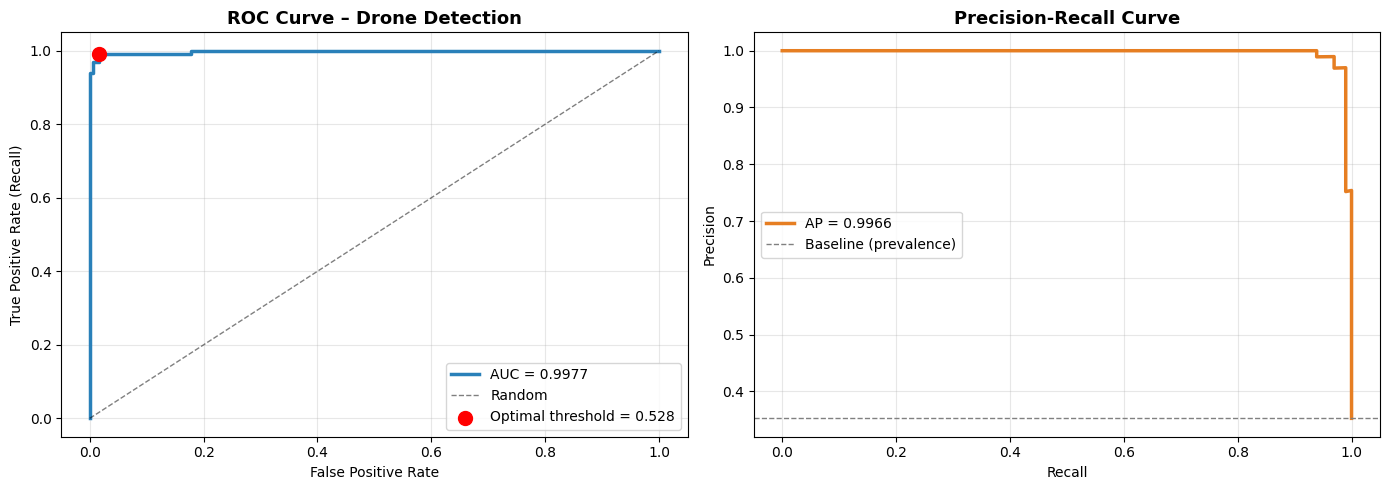

AUC-ROC            : 0.9977
Average Precision  : 0.9966
Optimal threshold  : 0.5278  (Youden's J)


In [4]:
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
roc_auc_val         = auc(fpr, tpr)

prec, rec, pr_thresh = precision_recall_curve(y_test, y_prob)
ap                   = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr, color="#2980b9", linewidth=2.5, label=f"AUC = {roc_auc_val:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_title("ROC Curve – Drone Detection", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# optimal threshold (Youden's J)
j_scores  = tpr - fpr
opt_idx   = np.argmax(j_scores)
opt_thresh = roc_thresh[opt_idx]
ax.scatter(fpr[opt_idx], tpr[opt_idx], color="red", zorder=5,
           s=100, label=f"Optimal threshold = {opt_thresh:.3f}")
ax.legend(fontsize=10)

# ── Precision-Recall ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(rec, prec, color="#e67e22", linewidth=2.5, label=f"AP = {ap:.4f}")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label="Baseline (prevalence)")
ax.set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC            : {roc_auc_val:.4f}")
print(f"Average Precision  : {ap:.4f}")
print(f"Optimal threshold  : {opt_thresh:.4f}  (Youden's J)")


## 4.4  Confusion matrix

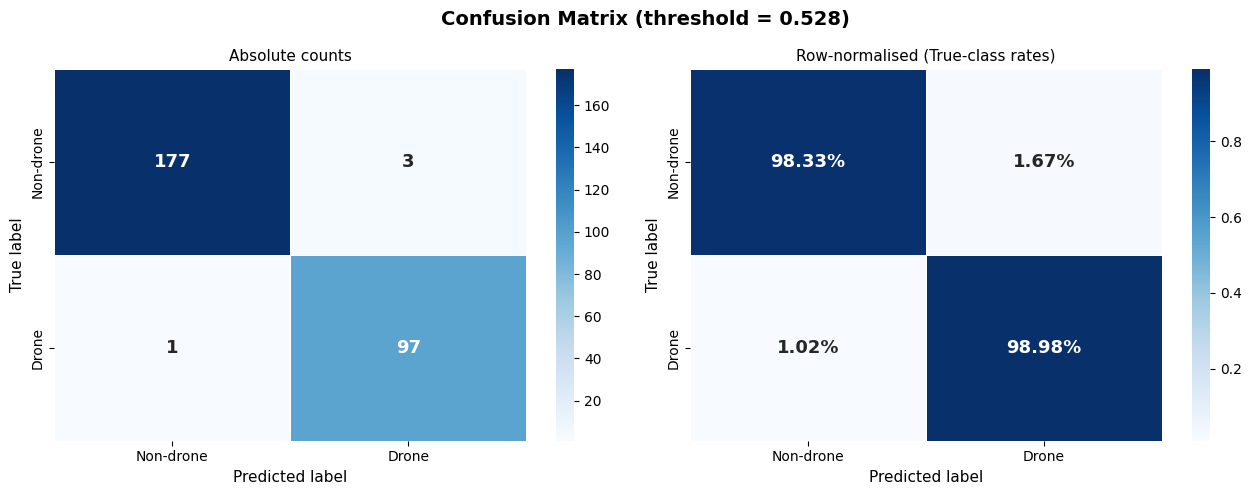

TP=97  FP=3  FN=1  TN=177
False Alarm Rate    : 1.67%
Miss Detection Rate : 1.02%


In [5]:
# ── Use optimal threshold ─────────────────────────────────────────────────────
y_pred_opt = (y_prob >= opt_thresh).astype(int)
cm         = confusion_matrix(y_test, y_pred_opt)
cm_norm    = confusion_matrix(y_test, y_pred_opt, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Confusion Matrix (threshold = {opt_thresh:.3f})", fontsize=14, fontweight="bold")

for ax, matrix, fmt, title in zip(
        axes,
        [cm,      cm_norm],
        ["d",     ".2%"],
        ["Absolute counts", "Row-normalised (True-class rates)"]):

    sns.heatmap(matrix, annot=True, fmt=fmt, ax=ax,
                cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"False Alarm Rate    : {fp/(fp+tn)*100:.2f}%")
print(f"Miss Detection Rate : {fn/(fn+tp)*100:.2f}%")


## 4.5  Classification report

In [6]:
report = classification_report(y_test, y_pred_opt,
                               target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).T
print(classification_report(y_test, y_pred_opt, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

   Non-drone       0.99      0.98      0.99       180
       Drone       0.97      0.99      0.98        98

    accuracy                           0.99       278
   macro avg       0.98      0.99      0.98       278
weighted avg       0.99      0.99      0.99       278



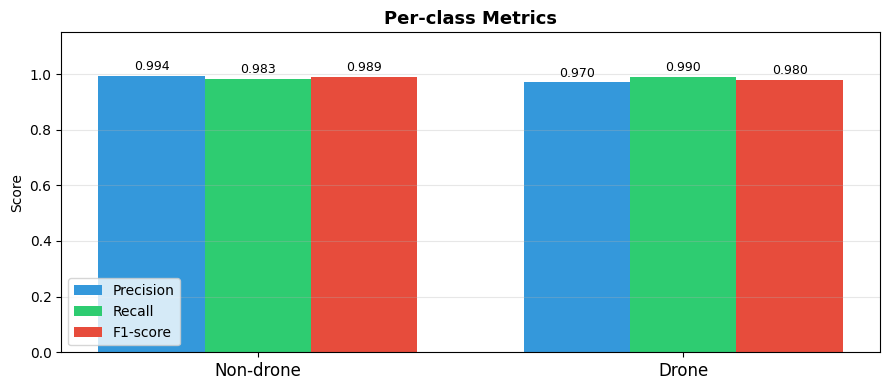

In [7]:
# ── Metric bar chart ──────────────────────────────────────────────────────────
metrics_plot = report_df.loc[CLASS_NAMES, ["precision","recall","f1-score"]]

fig, ax = plt.subplots(figsize=(9, 4))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
b1  = ax.bar(x - w,     metrics_plot["precision"],  w, label="Precision", color="#3498db")
b2  = ax.bar(x,         metrics_plot["recall"],     w, label="Recall",    color="#2ecc71")
b3  = ax.bar(x + w,     metrics_plot["f1-score"],   w, label="F1-score",  color="#e74c3c")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title("Per-class Metrics", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plots/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.6  Threshold sensitivity analysis

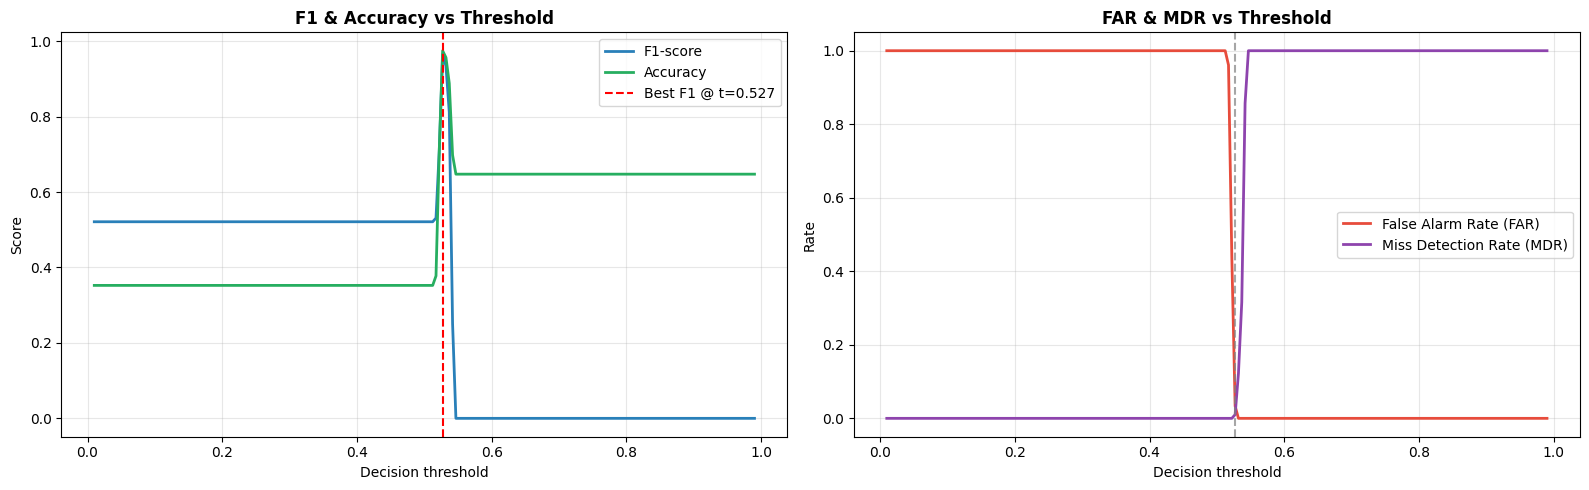

Best F1 threshold   : 0.5271
F1 at best threshold: 0.9652
FAR at best threshold: 3.33%
MDR at best threshold: 1.02%


In [8]:
thresholds = np.linspace(0.01, 0.99, 200)
results = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    f1_val = f1_score(y_test, yp, zero_division=0)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, yp, labels=[0, 1]).ravel()
    far  = fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0.0   # False alarm rate
    mdr  = fn_ / (fn_ + tp_) if (fn_ + tp_) > 0 else 0.0   # Miss detection rate
    acc  = (tp_ + tn_) / len(y_test)
    results.append({"threshold": t, "f1": f1_val, "far": far, "mdr": mdr, "accuracy": acc})

thresh_df = pd.DataFrame(results)
best_f1_row = thresh_df.loc[thresh_df["f1"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(thresh_df["threshold"], thresh_df["f1"],       label="F1-score",           color="#2980b9", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["accuracy"], label="Accuracy",            color="#27ae60", lw=2)
ax.axvline(best_f1_row["threshold"], color="red", linestyle="--",
           label=f"Best F1 @ t={best_f1_row['threshold']:.3f}")
ax.set_title("F1 & Accuracy vs Threshold", fontsize=12, fontweight="bold")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thresh_df["threshold"], thresh_df["far"], label="False Alarm Rate (FAR)",  color="#e74c3c", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["mdr"], label="Miss Detection Rate (MDR)", color="#8e44ad", lw=2)
ax.axvline(best_f1_row["threshold"], color="gray", linestyle="--", alpha=0.7)
ax.set_title("FAR & MDR vs Threshold", fontsize=12, fontweight="bold")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Rate")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best F1 threshold   : {best_f1_row['threshold']:.4f}")
print(f"F1 at best threshold: {best_f1_row['f1']:.4f}")
print(f"FAR at best threshold: {best_f1_row['far']*100:.2f}%")
print(f"MDR at best threshold: {best_f1_row['mdr']*100:.2f}%")


## 4.7  Prediction score distribution

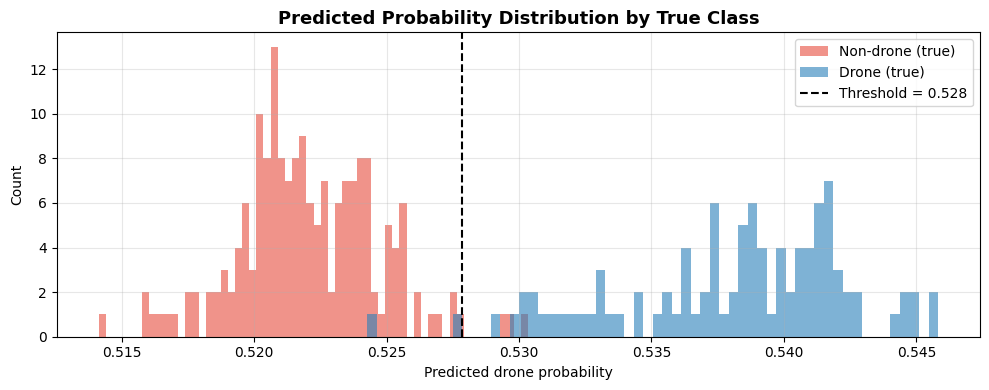

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_test == 0], bins=60, alpha=0.6, color="#e74c3c", label="Non-drone (true)")
ax.hist(y_prob[y_test == 1], bins=60, alpha=0.6, color="#2980b9", label="Drone (true)")
ax.axvline(opt_thresh, color="black", linestyle="--", lw=1.5, label=f"Threshold = {opt_thresh:.3f}")
ax.set_title("Predicted Probability Distribution by True Class", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted drone probability")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.8  Calibration curve

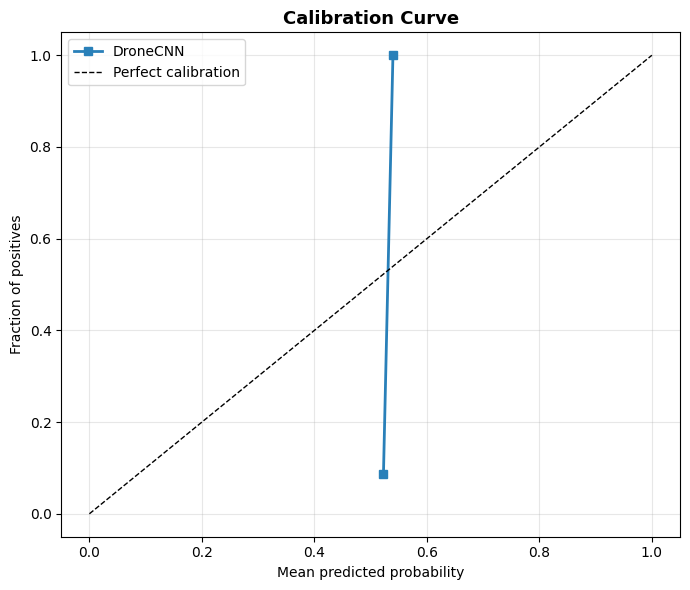

In [10]:
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=15)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, frac_pos, "s-", color="#2980b9", linewidth=2, markersize=6, label="DroneCNN")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_title("Calibration Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.9  SNR robustness simulation

Simulate degraded SNR by adding white Gaussian noise to the test features and measuring accuracy drop.

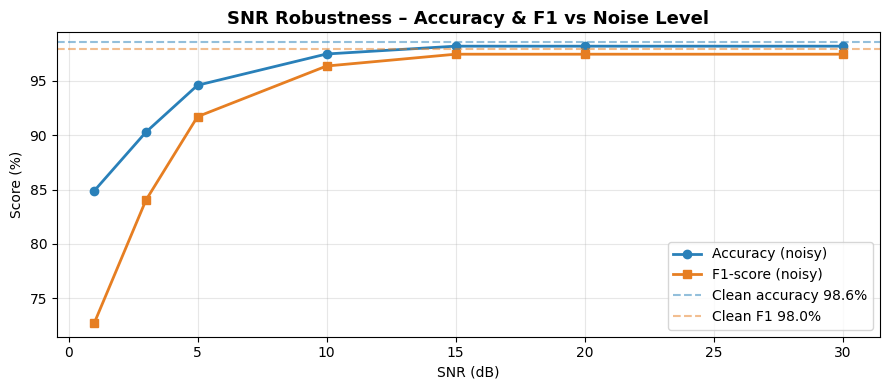

 snr_db  accuracy       f1
      1  0.848921 0.727273
      3  0.902878 0.840237
      5  0.946043 0.917127
     10  0.974820 0.963731
     15  0.982014 0.974619
     20  0.982014 0.974619
     30  0.982014 0.974619


In [11]:
snr_levels = [1, 3, 5, 10, 15, 20, 30]   # dB
snr_results = []

for snr_db in snr_levels:
    snr_lin   = 10 ** (snr_db / 10.0)
    signal_power = np.mean(X_test ** 2)
    noise_std    = np.sqrt(signal_power / snr_lin)
    rng          = np.random.default_rng(SEED)
    X_noisy      = X_test + rng.normal(0, noise_std, X_test.shape).astype(np.float32)

    prob_noisy  = model.predict(X_noisy, batch_size=128, verbose=0).ravel()
    acc_noisy   = np.mean((prob_noisy >= opt_thresh).astype(int) == y_test)
    f1_noisy    = f1_score(y_test, (prob_noisy >= opt_thresh).astype(int), zero_division=0)
    snr_results.append({"snr_db": snr_db, "accuracy": acc_noisy, "f1": f1_noisy})

snr_df = pd.DataFrame(snr_results)

# clean baseline
clean_acc = np.mean(y_pred_opt == y_test)
clean_f1  = f1_score(y_test, y_pred_opt)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(snr_df["snr_db"], snr_df["accuracy"] * 100, "o-", lw=2, color="#2980b9", label="Accuracy (noisy)")
ax.plot(snr_df["snr_db"], snr_df["f1"] * 100,       "s-", lw=2, color="#e67e22", label="F1-score (noisy)")
ax.axhline(clean_acc * 100, linestyle="--", color="#2980b9", alpha=0.5, label=f"Clean accuracy {clean_acc*100:.1f}%")
ax.axhline(clean_f1  * 100, linestyle="--", color="#e67e22", alpha=0.5, label=f"Clean F1 {clean_f1*100:.1f}%")
ax.set_title("SNR Robustness – Accuracy & F1 vs Noise Level", fontsize=13, fontweight="bold")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Score (%)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/snr_robustness.png", dpi=150, bbox_inches="tight")
plt.show()
print(snr_df.to_string(index=False))


## 4.10  Final results summary

In [12]:
final_acc  = np.mean(y_pred_opt == y_test)
final_f1   = f1_score(y_test, y_pred_opt)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

summary = {
    "Test accuracy (%)":          round(final_acc * 100, 2),
    "F1-score (drone)":           round(final_f1, 4),
    "AUC-ROC":                    round(roc_auc_val, 4),
    "Average Precision":          round(ap, 4),
    "Precision (drone %)":        round(tp/(tp+fp)*100, 2) if (tp+fp)>0 else 0,
    "Recall (drone %)":           round(tp/(tp+fn)*100, 2) if (tp+fn)>0 else 0,
    "False Alarm Rate (%)":       round(fp/(fp+tn)*100, 2) if (fp+tn)>0 else 0,
    "Miss Detection Rate (%)":    round(fn/(fn+tp)*100, 2) if (fn+tp)>0 else 0,
    "Optimal threshold":          round(opt_thresh, 4),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
print("=" * 45)
print("        DRONEPRINT CNN – TEST RESULTS")
print("=" * 45)
print(summary_df.to_string())
print("=" * 45)

with open("evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved evaluation_summary.json")


        DRONEPRINT CNN – TEST RESULTS
                           Value
Test accuracy (%)        98.5600
F1-score (drone)          0.9798
AUC-ROC                   0.9977
Average Precision         0.9966
Precision (drone %)      97.0000
Recall (drone %)         98.9800
False Alarm Rate (%)      1.6700
Miss Detection Rate (%)   1.0200
Optimal threshold         0.5278


TypeError: Object of type float32 is not JSON serializable

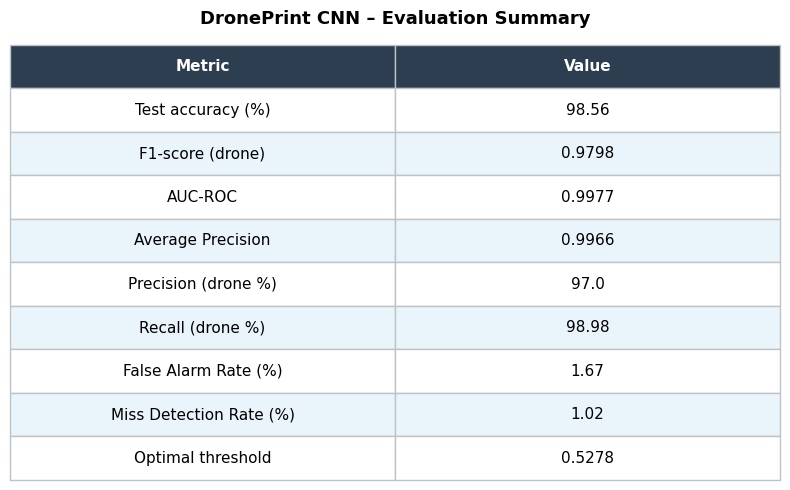

In [13]:
# ── Summary table as figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis("off")
rows = [[k, str(v)] for k, v in summary.items()]
table = ax.table(cellText=rows, colLabels=["Metric", "Value"],
                 cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eaf4fb")
    cell.set_edgecolor("#bdc3c7")
plt.title("DronePrint CNN – Evaluation Summary", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("plots/evaluation_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
